In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Collection & Understanding

In [3]:
pd.set_option('display.max_columns', None)

df = pd.read_csv("D:\shopper_spectrum\data\online_retail.csv",encoding='latin1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2022 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2022 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2022 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2022 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2022 08:26,3.39,17850.0,United Kingdom


In [4]:
# Dataset Structure (No of Rows and Columns)
df.shape

(541909, 8)

In [5]:
# Datatypes of Attributes
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [6]:
# Null Value Present
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Data Preprocessing

In [7]:
# Duplicate entries which can draw a signifiant change in our Deliverables
print(f"Number of Duplicated Rows: {df.duplicated().sum()}")

Number of Duplicated Rows: 5268


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print(f"No of Duplicated Rows after removing: {df.duplicated().sum()}")

No of Duplicated Rows after removing: 0


In [10]:
# InvoiceDate column datatype is type casted to Data-Time format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],format='%d-%m-%Y %H:%M')
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


##### Remove rows with missing CustomerID

In [12]:
print(f"No of Missing CustomerID: {df['CustomerID'].isnull().sum()}")

No of Missing CustomerID: 135037


In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
print(f"No of Missing CustomerID after dropping: {df['CustomerID'].isnull().sum()}")

No of Missing CustomerID after dropping: 0


In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


##### Exclude cancelled invoices (InvoiceNo starting with 'C')

In [16]:
cancelled_invoice = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print(f"No of cancelled_invoices present = {cancelled_invoice}")

No of cancelled_invoices present = 8872


In [17]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France


In [18]:
df.shape

(392732, 8)

#### •	Remove negative or zero quantities and prices

In [19]:
print(f"Quantity Negative/Zero {(df['Quantity']<=0).sum()}")

Quantity Negative/Zero 0


In [20]:
print(f"Negative/zero price {(df['UnitPrice']<=0).sum()}")

Negative/zero price 40


##### Creating the dataframe with the Quantity and price greater than 0

In [21]:
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)]
df.shape

(392692, 8)

##### Final Check of Null values present

In [22]:
print(f"Final cleaned shape of dataset: {df.shape}")
print(df.isnull().sum())

Final cleaned shape of dataset: (392692, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


### Exploratory Data Analysis (EDA)

##### Analyze transaction volume by country

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


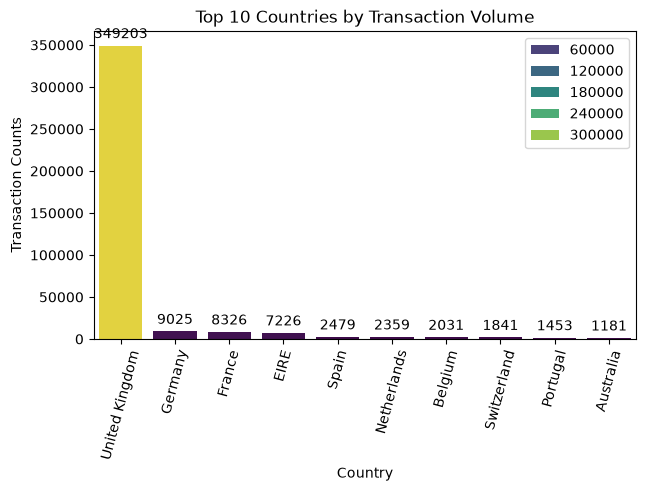

In [53]:
country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(7,4))
x = sns.barplot(x=country_counts.index, y=country_counts.values,hue=country_counts.values,palette='viridis')
plt.title("Top 10 Countries by Transaction Volume")
plt.xlabel("Country")
plt.ylabel("Transaction Counts")
plt.xticks(rotation=75)
for i in x.containers:
    x.bar_label(i,padding=3)
plt.show()


##### •	Identify top-selling products

In [34]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


##### 1. By quantity sold:

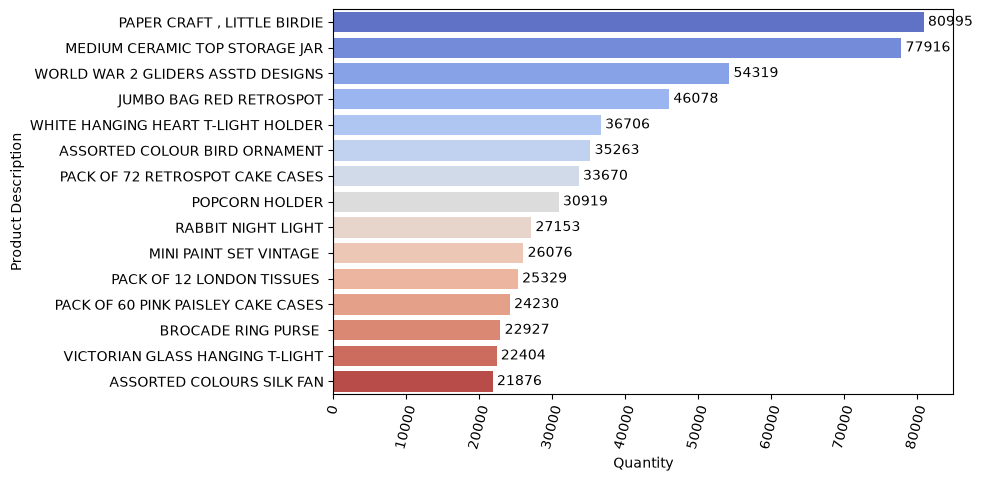

In [50]:
top_selling = df.groupby("Description")['Quantity'].sum().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(8,5))
top = sns.barplot(data=top_selling,y='Description',x='Quantity',hue='Description',palette='coolwarm')
plt.xlabel('Quantity')
plt.ylabel('Product Description')
plt.xticks(rotation=75)
for i in top.containers:
    top.bar_label(i,padding=3)
plt.show()

##### 2. By Revenue  -  Quantity * UnitPrice

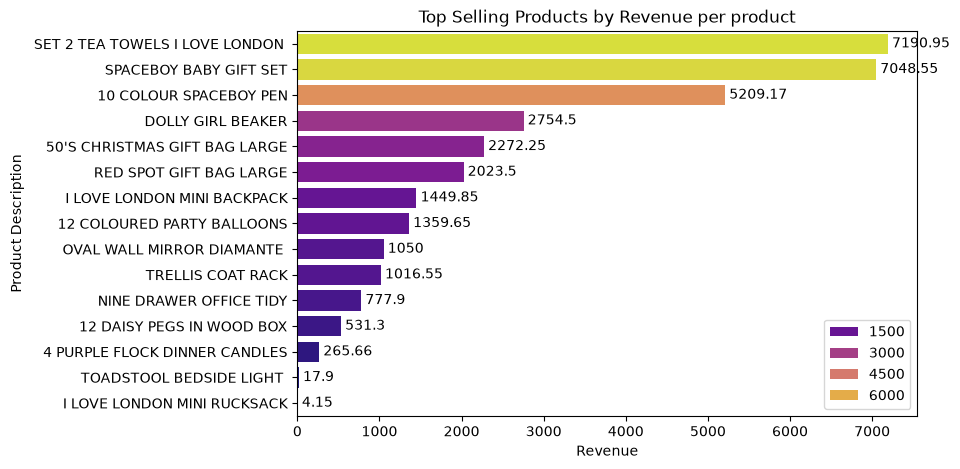

In [66]:
df['Total_price'] = df['Quantity']*df['UnitPrice']

top_products_reveneue = df.groupby('Description')['Total_price'].sum().head(15).sort_values(ascending=False)

plt.figure(figsize=(8,5))
rev = sns.barplot(x=top_products_reveneue.values,y=top_products_reveneue.index,hue=top_products_reveneue.values,palette='plasma')
plt.title('Top Selling Products by Revenue per product')
plt.xlabel('Revenue')
plt.ylabel('Product Description')
for i in rev.containers:
    rev.bar_label(i,padding=3)
plt.show()

### Purchase trends over time

In [56]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [57]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

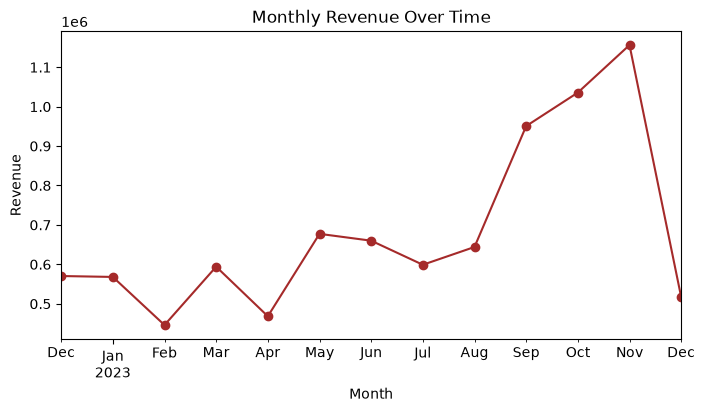

In [78]:
monthly_trend = df.groupby('InvoiceMonth')['Total_price'].sum()

plt.figure(figsize=(8,4))
monthly_trend.plot(kind='line',marker='o',color="brown")
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

#### Plot RFM distributions, elbow curves, cluster profiles, recommendation heatmap

###### The Core of Customer Segmentation Part : RFM
###### snapshot date (reference point to calculate Recency from — typically one day after the last transaction in the dataset):

#### Snapshot_date

In [79]:
snapshot_date = df['InvoiceDate'].max()+pd.Timedelta(days=1)
print(snapshot_date)

2023-12-10 12:50:00


#### Compute Recency, Frequency, Monetary per customer:

In [92]:
recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency_df['Recency'] = (snapshot_date - recency_df['InvoiceDate']).dt.days
recency_df.head(10)

,CustomerID,InvoiceDate,Recency
0,12346.0,2023-01-18 10:01:00,326
1,12347.0,2023-12-07 15:52:00,2
2,12348.0,2023-09-25 13:13:00,75
3,12349.0,2023-11-21 09:51:00,19
4,12350.0,2023-02-02 16:01:00,310
5,12352.0,2023-11-03 14:37:00,36
6,12353.0,2023-05-19 17:47:00,204
7,12354.0,2023-04-21 13:11:00,232
8,12355.0,2023-05-09 13:49:00,214
9,12356.0,2023-11-17 08:40:00,23


##### Frequency = Grouping CustomerID and total number of Invoice per customer

In [88]:
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.columns = ['CustomerID','Frequency']   # Renameing the column names in above Dataframe of frequency
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


##### Monetary = Revenue generated from each unique customer 

In [90]:
monetary_df = df.groupby('CustomerID')['Total_price'].sum().reset_index()
monetary_df.columns = ['CustomerID','Monetary']
monetary_df.head(10)

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
5,12352.0,2506.04
6,12353.0,89.00
7,12354.0,1079.40
8,12355.0,459.40
9,12356.0,2811.43


##### Merging Recency, Frequency and Monetary DataFrames into 1

In [94]:
rfm = recency_df[['CustomerID','Recency']].merge(frequency_df,on='CustomerID').merge(monetary_df,on='CustomerID')
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [95]:
rfm.shape

(4338, 4)

In [96]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='str')

In [97]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [98]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB


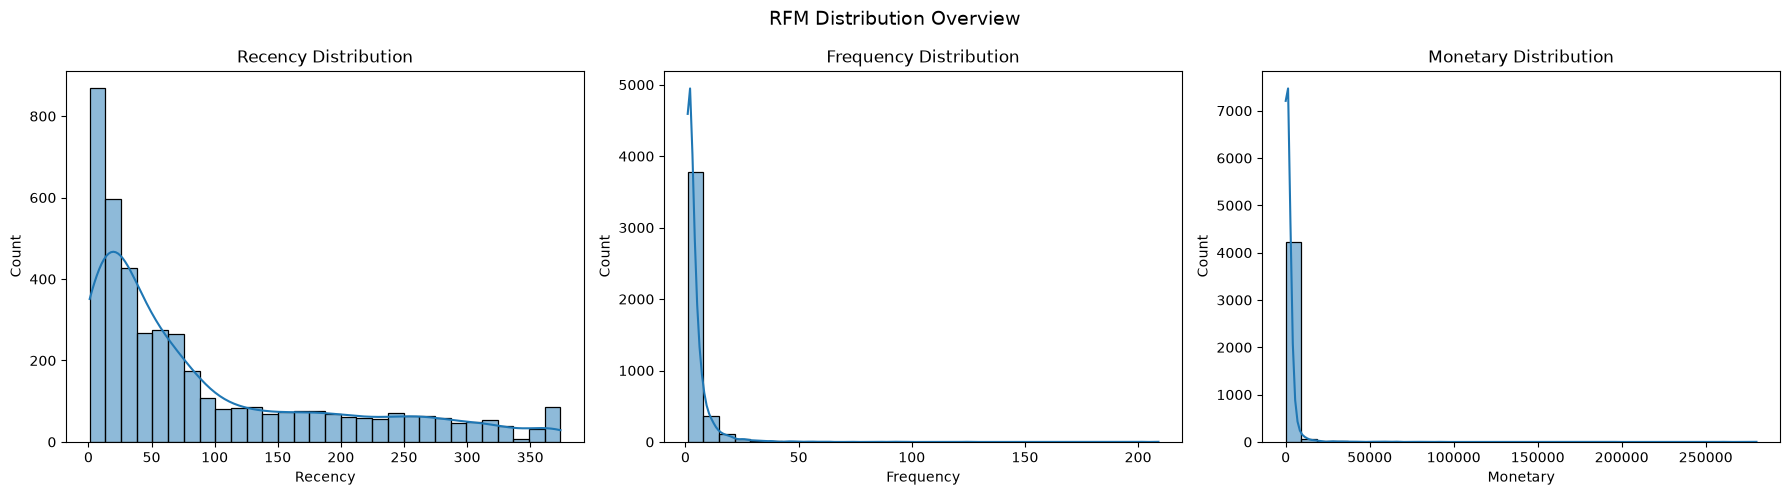

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], kde=True)
axes[2].set_title('Monetary Distribution')

fig.suptitle('RFM Distribution Overview', fontsize=14)
plt.tight_layout()
plt.show()

#### Prepare the data — select RFM columns and scale them:

In [109]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.head()


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


Why scale: KMeans uses distance calculations, and Monetary (which can be in the thousands) would completely dominate Recency (in days) and Frequency (small counts) if left unscaled. StandardScaler puts all three on the same footing (mean 0, standard deviation 1).

#### 2. Elbow method — test a range of cluster counts:


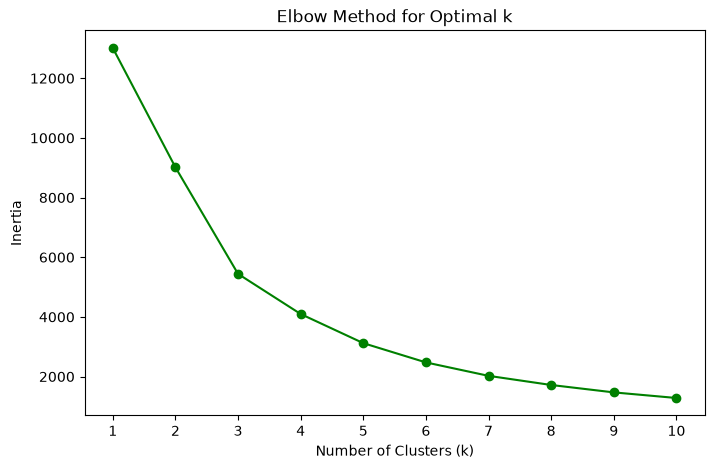

In [110]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o',color="Green")
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

What to look for: the "elbow" is the point where the line stops dropping sharply and starts flattening out — that's your candidate for optimal k. Often lands around k=3, 4, or 5 for RFM data.

#### Silhouette score — a second opinion to confirm the elbow:

k=2, Silhouette Score=0.8958
k=3, Silhouette Score=0.5942
k=4, Silhouette Score=0.6162
k=5, Silhouette Score=0.6165
k=6, Silhouette Score=0.5983
k=7, Silhouette Score=0.5165
k=8, Silhouette Score=0.4859
k=9, Silhouette Score=0.4784
k=10, Silhouette Score=0.4792


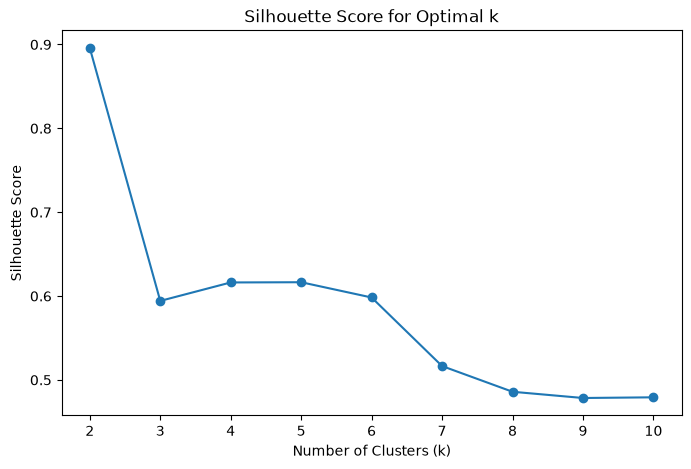

In [111]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

k=5 is a very close, defensible alternative if you find the resulting clusters split further into a meaningful 5th group (e.g., separating "Occasional" into two sub-behaviors) — but start with k=4 first since it maps directly to your brief.

In [112]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [113]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


Cluster Table to Dataframe to see the customer segmentation better:

In [114]:
cluster_labels = {
    2: 'High-Value',
    3: 'Regular',
    0: 'Occasional',
    1: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Regular
1,12347.0,2,7,4310.00,0,Occasional
2,12348.0,75,4,1797.24,0,Occasional
3,12349.0,19,1,1757.55,0,Occasional
4,12350.0,310,1,334.40,1,At-Risk


In [115]:
print(rfm['Segment'].value_counts())

Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64
